### What is Python Threading?
Threading is a sequence of instructions in a program that can be executed independently of the remaining process. You can see them as different units of your process that do jobs independently when scheduled. If they need to wait for a slow external operation to finish (such as a network request, or disk access), they sleep for a while and enable the scheduler to spend time executing another thread. 

### What is the Process?
A process is an executable instance of a computer program. Usually, a process is executed in a single sequence of control flow. 

### Advantages of Threading
Threaded programs run faster on computer systems that have multiple CPUs. 
Threads of a process can share the memory of global variables. If the variable's value is changed in one thread, it is applicable for all threads.

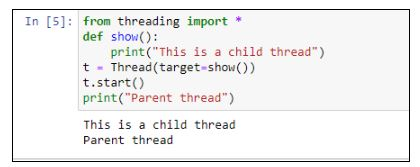

            Fig: Basic Python threading program
The above code executes as follows. We have imported the threading module and created a method thread labeled 't.' This thread 't' will run show() function because that is the target of a particular thread. 

## There are two types of thread:

Daemon thread
Non-daemon thread

### Daemon Thread
A daemon thread runs without blocking the main program when it exits and when associated daemon threads are also killed.

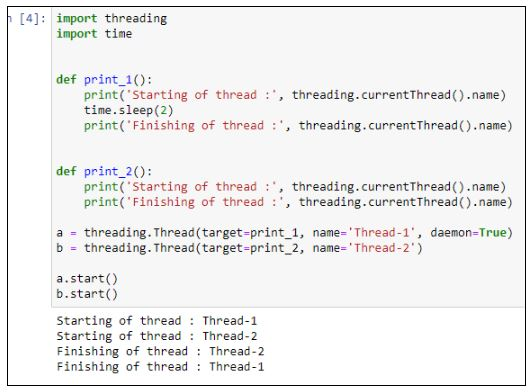
                    Fig: Daemon thread

We create a daemon thread by adding extra argument daemon = true. 

We added an extra argument—daemon = true—which created a daemon thread.

### Python Threading Functions
1. threading.active_count()
 This function tells us about the number of threads in execution.

Example:

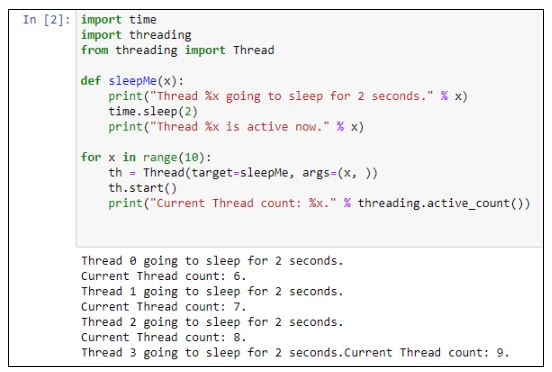

                         Fig: threading.active_count()

### 2. threading.main_thread()
This function returns the main thread in the program.

Example:


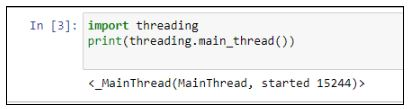
                    
                     
                     Fig: threading.main_thread()

### 3. threading.Timer()
This function is used to create a new thread and specify the time after which it should start. Once it starts, it should call the specified function.

Example:

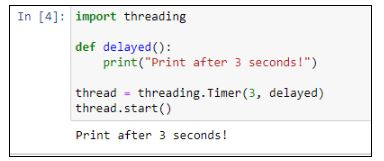


                      Fig: threading.Timer()

### Synchronization Using Lock
The lock helps us in the synchronization of two or more threads. It has two primary methods: acquire() and release().

acquire() method is used to acquire the lock. 

release() is used to free an acquired lock. 

Example:


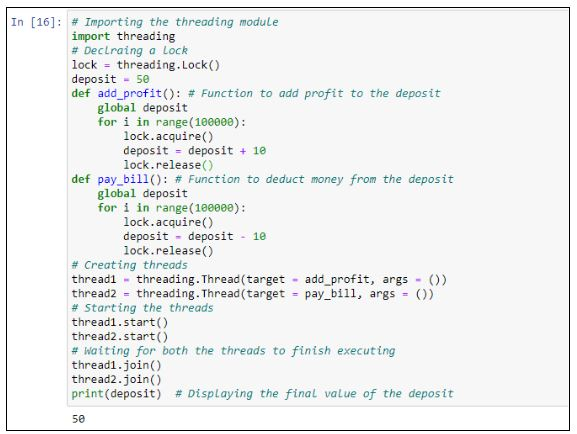



          Fig: lock() function in Python threading

### Multithreaded Priority Queue
The Queue module allows you to create a new queue object that can hold a specific number of items. There are following methods to control the Queue −


get() − The get() removes and returns an item from the queue.

put() − The put adds item to a queue.

qsize() − The qsize() returns the number of items that are currently in the queue.

empty() − The empty( ) returns True if queue is empty; otherwise, False.

full() − the full() returns True if queue is full; otherwise, False.

In [12]:
import queue
import threading
import time

exitFlag = 0

class myThread (threading.Thread):
   def __init__(self, threadID, name, q):
      threading.Thread.__init__(self)
      self.threadID = threadID
      self.name = name
      self.q = q
   def run(self):
      print ("Starting " + self.name)
      process_data(self.name, self.q)
      print ("Exiting " + self.name)

def process_data(threadName, q):
   while not exitFlag:
      queueLock.acquire()
      if not workQueue.empty():
         data = q.get()
         queueLock.release()
         print ("%s processing %s" % (threadName, data))
      else:
         queueLock.release()
         time.sleep(1)

threadList = ["Thread-1", "Thread-2", "Thread-3"]
nameList = ["One", "Two", "Three", "Four", "Five"]
queueLock = threading.Lock()
workQueue = queue.Queue(10)
threads = []
threadID = 1

# Create new threads
for tName in threadList:
   thread = myThread(threadID, tName, workQueue)
   thread.start()
   threads.append(thread)
   threadID += 1

# Fill the queue
queueLock.acquire()
for word in nameList:
   workQueue.put(word)
queueLock.release()

# Wait for queue to empty
while not workQueue.empty():
   pass

# Notify threads it's time to exit
exitFlag = 1

# Wait for all threads to complete
for t in threads:
   t.join()
print ("Exiting Main Thread")

Starting Thread-1
Starting Thread-2
Starting Thread-3
Thread-1 processing OneThread-2 processing Two
Thread-2 processing Three
Thread-2 processing Four
Thread-2 processing Five

Exiting Thread-1
Exiting Thread-2
Exiting Thread-3
Exiting Main Thread


### Thread Life Cycle
A thread object goes through different stages during its life cycle. When a new thread object is created, it must be started, which calls the run() method of thread class. This method contains the logic of the process to be performed by the new thread. The thread completes its task as the run() method is over, and the newly created thread merges with the main thread.

While a thread is running, it may be paused either for a predefined duration or it may be asked to pause till a certain event occurs. The thread resumes after the specified interval or the process is over.


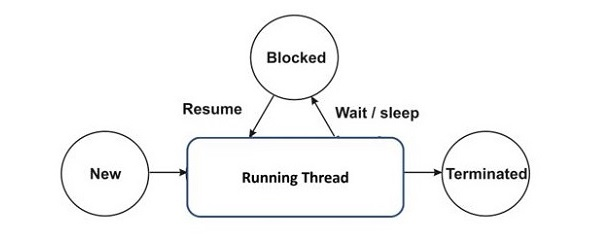

### States of a Thread Life Cycle in Python
Following are the stages of the Python Thread life cycle −

Creating a Thread − To create a new thread in Python, you typically use the Thread class from the threading module.
Starting a Thread − Once a thread object is created, it must be started by calling its start() method. This initiates the thread's activity and invokes its run() method in a separate thread.
Paused/Blocked State − Threads can be paused or blocked for various reasons, such as waiting for I/O operations to complete or another thread to perform a task. This is typically managed by calling its join() method. This blocks the calling thread until the thread being joined terminates.
Synchronizing Threads − Synchronization ensures orderly execution and shared resource management among threads. This can be done by using synchronization primitives like locks, semaphores, or condition variables.
Termination − A thread terminates when its run() method completes execution, either by finishing its task or encountering an exception.

### Example: Python Thread Life Cycle Demonstration
This example demonstrates the thread life cycle in Python by showing thread creation, starting, execution, and synchronization with the main thread.

In [13]:
import threading

def func(x):
   print('Current Thread Details:', threading.current_thread())
   for n in range(x):
      print('{} Running'.format(threading.current_thread().name), n)
   print('Internal Thread Finished...')

# Create thread objects
t1 = threading.Thread(target=func, args=(2,))
t2 = threading.Thread(target=func, args=(3,))

# Start the threads
print('Thread State: CREATED')
t1.start()
t2.start()

# Wait for threads to complete
t1.join()
t2.join()
print('Threads State: FINISHED')

# Simulate main thread work
for i in range(3):
   print('Main Thread Running', i)

print("Main Thread Finished...")

Thread State: CREATED
Current Thread Details: <Thread(Thread-10 (func), started 132788510521024)>
Thread-10 (func) Running 0
Thread-10 (func) Running 1
Internal Thread Finished...
Current Thread Details: <Thread(Thread-11 (func), started 132788460164800)>
Thread-11 (func) Running 0
Thread-11 (func) Running 1
Thread-11 (func) Running 2
Internal Thread Finished...
Threads State: FINISHED
Main Thread Running 0
Main Thread Running 1
Main Thread Running 2
Main Thread Finished...


### Example: Using a Synchronization Primitive
Here is another example demonstrates the thread life cycle in Python, including creation, starting, running, and termination states, along with synchronization using a semaphore.



In [14]:
import threading
import time

# Create a semaphore 
semaphore = threading.Semaphore(2)

def worker():
   with semaphore:
      print('{} has started working'.format(threading.current_thread().name))
      time.sleep(2)
      print('{} has finished working'.format(threading.current_thread().name))

# Create a list to keep track of thread objects
threads = []

# Create and start 5 threads
for i in range(5):
   t = threading.Thread(target=worker, name='Thread-{}'.format(i+1))
   threads.append(t)
   print('{} has been created'.format(t.name))
   t.start()

# Wait for all threads to complete
for t in threads:
   t.join()
   print('{} has terminated'.format(t.name))

print('Threads State: All are FINISHED')
print("Main Thread Finished...")

Thread-1 has been created
Thread-1 has started working
Thread-2 has been created
Thread-2 has started working
Thread-3 has been created
Thread-4 has been created
Thread-5 has been created
Thread-1 has finished working
Thread-2 has finished working
Thread-3 has started working
Thread-1 has terminated
Thread-2 has terminated
Thread-4 has started working
Thread-3 has finished working
Thread-5 has started working
Thread-3 has terminated
Thread-4 has finished working
Thread-4 has terminated
Thread-5 has finished working
Thread-5 has terminated
Threads State: All are FINISHED
Main Thread Finished...


### Python - Creating a Thread
Creating a thread in Python involves initiating a separate flow of execution within a program, allowing multiple operations to run concurrently. This is particularly useful for performing tasks simultaneously, such as handling various I/O operations in parallel.

Python provides multiple ways to create and manage threads.

Creating a thread using the threading module is generally recommended due to its higher-level interface and additional functionalities.

On the other hand, the _thread module offers a simpler, lower-level approach to create and manage threads, which can be useful for straightforward, low-overhead threading tasks.


### Creating Threads with Functions
You can create threads by using the Thread class from the threading module. In this approach, you can create a thread by simply passing a function to the Thread object. Here are the steps to start a new thread −


Define a function that you want the thread to execute.
Create a Thread object using the Thread class, passing the target function and its arguments.
Call the start method on the Thread object to begin execution.
Optionally, call the join method to wait for the thread to complete before proceeding.


Example
The following example demonstrates concurrent execution using threads in Python. It creates and starts multiple threads that execute different tasks concurrently by specifying user-defined functions as targets within the Thread class.

In [15]:
from threading import Thread

def addition_of_numbers(x, y):
   result = x + y
   print('Addition of {} + {} = {}'.format(x, y, result))

def cube_number(i):
   result = i ** 3
   print('Cube of {} = {}'.format(i, result))

def basic_function():
   print("Basic function is running concurrently...")

Thread(target=addition_of_numbers, args=(2, 4)).start()  
Thread(target=cube_number, args=(4,)).start() 
Thread(target=basic_function).start()

Addition of 2 + 4 = 6
Cube of 4 = 64
Basic function is running concurrently...


Creating Threads by Extending the Thread Class
Another approach to creating a thread is by extending the Thread class. This approach involves defining a new class that inherits from Thread and overriding its __init__ and run methods. Here are the steps to start a new thread −

Define a new subclass of the Thread class.
Override the __init__ method to add additional arguments.
Override the run method to implement the thread's behavior.


Example
This example demonstrates how to create and manage multiple threads using a custom MyThread class that extends the threading.Thread class in Python.

In [16]:
import threading
import time

exitFlag = 0

class myThread (threading.Thread):
   def __init__(self, threadID, name, counter):
      threading.Thread.__init__(self)
      self.threadID = threadID
      self.name = name
      self.counter = counter
   def run(self):
      print ("Starting " + self.name)
      print_time(self.name, 5, self.counter)
      print ("Exiting " + self.name)

def print_time(threadName, counter, delay):
   while counter:
      if exitFlag:
         threadName.exit()
      time.sleep(delay)
      print ("%s: %s" % (threadName, time.ctime(time.time())))
      counter -= 1

# Create new threads
thread1 = myThread(1, "Thread-1", 1)
thread2 = myThread(2, "Thread-2", 2)

# Start new Threads
thread1.start()
thread2.start()
print ("Exiting Main Thread")

Starting Thread-1Starting Thread-2
Exiting Main Thread

Thread-1: Thu May 28 23:15:19 2026
Thread-2: Thu May 28 23:15:20 2026
Thread-1: Thu May 28 23:15:20 2026
Thread-1: Thu May 28 23:15:21 2026
Thread-2: Thu May 28 23:15:22 2026
Thread-1: Thu May 28 23:15:22 2026
Thread-1: Thu May 28 23:15:23 2026
Exiting Thread-1
Thread-2: Thu May 28 23:15:24 2026
Thread-2: Thu May 28 23:15:26 2026
Thread-2: Thu May 28 23:15:28 2026
Exiting Thread-2


Creating Threads using start_new_thread() Function
The start_new_thread() function included in the _thread module is used to create a new thread in the running program. This module offers a low-level approach to threading. It is simpler but does not have some of the advanced features provided by the threading module.

Here is the syntax of the _thread.start_new_thread() Function

### _thread.start_new_thread ( function, args[, kwargs] )


This function starts a new thread and returns its identifier. The function parameter specifies the function that the new thread will execute. Any arguments required by this function can be passed using args and kwargs.

Example

In [17]:
import _thread
import time
# Define a function for the thread
def thread_task( threadName, delay):
   for count in range(1, 6):
      time.sleep(delay)
      print ("Thread name: {} Count: {}".format ( threadName, count ))

# Create two threads as follows
try:
    _thread.start_new_thread( thread_task, ("Thread-1", 2, ) )
    _thread.start_new_thread( thread_task, ("Thread-2", 4, ) )
except:
   print ("Error: unable to start thread")

while True:
   pass
   
thread_task("test", 0.3)

Thread name: Thread-1 Count: 1
Thread name: Thread-2 Count: 1
Thread name: Thread-1 Count: 2
Thread name: Thread-1 Count: 3
Thread name: Thread-2 Count: 2
Thread name: Thread-1 Count: 4
Thread name: Thread-1 Count: 5
Thread name: Thread-2 Count: 3
Thread name: Thread-2 Count: 4
Thread name: Thread-2 Count: 5


KeyboardInterrupt: 

In [ ]:
from time import sleep, time 

start_time = time()

def somthing():
    print("Going to sleep....")
    sleep(1)
    print("Woken up ....")

somthing()
somthing()

end_time = time()

print(f"Main Thread Ended in {end_time - start_time} seconds")

## For a  given number print Square and Cube of Every Number.
for example : - input : [2,3,8,9]
                Square Output : [4,9,64,81]
                Cube Output : [8,27,512,729]

In [ ]:
import time 
def cal_Square(numbers):
    print("Calculate Square Number")
    for n in numbers:
        time.sleep(0.2)
        print('Square:', n*n)
def cal_Cube(numbers):
    print("Calculate Cube Numbers")
    for n in numbers:
        time.sleep(0.2)
        print('Cube:', n*n*n)
arr = [2,3,8,9]

t = time.time()
cal_Square(arr)
cal_Cube(arr)

print("done in :", time.time() -t)

print("Hah.. I am done with all my work now")

In [ ]:
import time 
import threading

def cal_Square(numbers):
    print("Calculate Square Number")
    for n in numbers:
        time.sleep(0.2)
        print('Square:', n*n)
def cal_Cube(numbers):
    print("Calculate Cube Numbers")
    for n in numbers:
        time.sleep(0.2)
        print('Cube:', n*n*n)
arr = [2,3,8,9]

t = time.time()
t1 = threading.Thread(target = cal_Square, args = (arr,))
t2 = threading.Thread(target = cal_Cube, args = (arr,))

t1.start()
t2.start()

t1.join()
t2.join()

print("done in :", time.time() -t)

print("Hah.. I am done with all my work now")

In [ ]:
from time import sleep, time 

start_time = time()

def somthing():
    print("Going to sleep....")
    sleep(1)
    print("Woken up ....")

for _ in range(10):
    somthing()


end_time = time()

print(f"Main Thread Ended in {end_time - start_time} seconds")

In [ ]:
from time import sleep, time 
import threading

start_time = time()

def somthing(id):
    print(f"Going to sleep....{id}")
    sleep(1)
    print(f"Woken up ....{id}")

t1 = threading.Thread(target=somthing, args = [0])
t1.start()
t1.join()
end_time = time()

print(f"Main Thread Ended in {end_time - start_time} seconds")

In [ ]:
from time import sleep, time 
import threading

start_time = time()

def somthing(id):
    print(f"Going to sleep....{id}")
    sleep(1)
    print(f"Woken up ....{id}")

t1 = threading.Thread(target=somthing, args = [0])
t2 = threading.Thread(target=somthing, args = [1])
t1.start()
t2.start()

t1.join()
t2.join()
end_time = time()

print(f"Main Thread Ended in {end_time - start_time} seconds")

In [ ]:
from time import sleep, time 
import threading

start_time = time()

def somthing(id):
    print(f"Going to sleep....{id}")
    sleep(1)
    print(f"Woken up ....{id}")
threads = [threading.Thread(target= somthing, args=[i]) for i in range(10)]


for thread in threads:
    thread.start()
for thread in threads:
    thread.join()
    
end_time = time()

print(f"Main Thread Ended in {end_time - start_time} seconds")

In [1]:
import threading
balance = 200

def deposit(amount,times):
    global balance

    for _ in range(times):
        balance+=amount

def withdraw(amount,times):
    global balance
    
    for _ in range(times):
        balance-=amount

deposit_thread = threading.Thread(target = deposit, args = [1,1000000])
withdraw_thread = threading.Thread(target = withdraw, args = [1,1000000])

deposit_thread.start()
withdraw_thread.start()

deposit_thread.join()
withdraw_thread.join()

print(balance)


200


In [ ]:
import threading

balance = 200

lock = threading.Lock()

def deposit(amount, times, lock):
    global balance

    for _ in range(times):
        lock.acquire()
        balance += amount
        lock.release()

def withdraw(amount, times, lock):
    global balance

    for _ in range(times):
        lock.acquire()
        balance -= amount
        lock.release()

deposit_thread = threading.Thread(
    target=deposit,
    args=[1, 1000, lock]
)

withdraw_thread = threading.Thread(
    target=withdraw,
    args=[1, 1000, lock]
)

deposit_thread.start()
withdraw_thread.start()

deposit_thread.join()
withdraw_thread.join()

print(balance)

In [4]:
from time import time,sleep
from concurrent.futures import ThreadPoolExecutor

start_time = time()

def somthing(id):
    print(f"Going to sleep....{id}")
    sleep(1)
    return f"woken up ....{id}"

with ThreadPoolExecutor() as executor:
    task = executor.submit(somthing, 0 )
    print(task.result())

end_time = time()
print(f"Main Thread Ended in {end_time-start_time} seconds")

Going to sleep....0
woken up ....0
Main Thread Ended in 1.002838373184204 seconds


In [5]:
from time import time,sleep
from concurrent.futures import ThreadPoolExecutor,as_completed

start_time = time()

def somthing(id):
    print(f"Going to sleep....{id}")
    sleep(1)
    return f"woken up ....{id}"

with ThreadPoolExecutor() as executor:
    task = [executor.submit(somthing, i ) for i in range(10)]

    for _ in as_completed(task):
        print(_.result())

end_time = time()
print(f"Main Thread Ended in {end_time-start_time} seconds")

Going to sleep....0
Going to sleep....1
Going to sleep....2
Going to sleep....3
Going to sleep....4
Going to sleep....5
Going to sleep....6
Going to sleep....7
Going to sleep....8woken up ....0

Going to sleep....9
woken up ....1
woken up ....2
woken up ....3
woken up ....4
woken up ....5
woken up ....6
woken up ....7
woken up ....8
woken up ....9
Main Thread Ended in 2.004746437072754 seconds


In [6]:
from time import time,sleep
from concurrent.futures import ThreadPoolExecutor,as_completed

start_time = time()

def somthing(id,sleep_time):
    print(f"Going to sleep....{id}")
    sleep(sleep_time)
    return f"woken up ....{id}"

with ThreadPoolExecutor() as executor:
    task = [executor.submit(somthing, i,10-i ) for i in range(10)]

    for _ in as_completed(task):
        print(_.result())

end_time = time()
print(f"Main Thread Ended in {end_time-start_time} seconds")

Going to sleep....0
Going to sleep....1
Going to sleep....2
Going to sleep....3
Going to sleep....4
Going to sleep....5
Going to sleep....6
Going to sleep....7
Going to sleep....8woken up ....7

Going to sleep....9
woken up ....6
woken up ....5
woken up ....9
woken up ....8
woken up ....4
woken up ....3
woken up ....2
woken up ....1
woken up ....0
Main Thread Ended in 10.004863739013672 seconds


In [10]:
from time import time, sleep
from concurrent.futures import ThreadPoolExecutor

start_time = time()

def somthing(id):
    print(f"Going to sleep....{id}")
    sleep(1)
    return f"woken up ....{id}"

ids = [0, 1, 2, 3, 4, 5]

with ThreadPoolExecutor() as executor:
    results = executor.map(somthing, ids)

    for result in results:
        print(result)

end_time = time()

print(f"Main Thread Ended in {end_time - start_time} seconds")

Going to sleep....0
Going to sleep....1
Going to sleep....2
Going to sleep....3
Going to sleep....4
Going to sleep....5
woken up ....0
woken up ....1
woken up ....2
woken up ....3
woken up ....4
woken up ....5
Main Thread Ended in 1.0058948993682861 seconds


In [11]:
from time import time, sleep
from concurrent.futures import ThreadPoolExecutor

start_time = time()

def somthing(id,sleep_time):
    print(f"Going to sleep....{id}")
    sleep(sleep_time)
    return f"woken up ....{id}"

ids = [0, 1, 2, 3, 4, 5]
sleep_time = [5,1,3,4,6,7]
with ThreadPoolExecutor() as executor:
    results = executor.map(somthing, ids,sleep_time)

    for result in results:
        print(result)

end_time = time()

print(f"Main Thread Ended in {end_time - start_time} seconds")

Going to sleep....0
Going to sleep....1
Going to sleep....2
Going to sleep....3
Going to sleep....4
Going to sleep....5
woken up ....0
woken up ....1
woken up ....2
woken up ....3
woken up ....4
woken up ....5
Main Thread Ended in 7.007909297943115 seconds


In [ ]:
import time
from concurrent.futures import ThreadPoolExecutor

def calc_square(numbers):
    for n in numbers:
        print("square", n*n)
        time.sleep(0.2)

def calc_cube(numbers):
    for n in numbers:
        print("cube", n*n*n)
        time.sleep(0.2)

arr = [2, 3, 8]
t = time.time()
with ThreadPoolExecutor() as ex:
    ex.submit(calc_square, arr)
    ex.submit(calc_cube, arr)


print("done in :", time.time() -t)

print("Hah.. I am done with all my work now")